# Team 22 (Introduction to Artificial Intelligence)
This project utilizes the Enron Email Dataset, a widely recognized collection of over 500,000 real-world emails from the Enron Corporation. The dataset, accessible at [Enron Email Dataset](https://www.cs.cmu.edu/~enron/), serves as a valuable resource for testing and evaluating machine learning and natural language processing (NLP) models. Its diversity and scale make it ideal for tackling challenges such as handling noise, ambiguity, and large volumes of textual data.

In this notebook, we implement and evaluate various machine learning models to classify emails into meaningful categories, demonstrating their effectiveness in automating email management and enhancing organizational efficiency.


## Cleaning script used for preprocessing the dataset

The script below was used by the team to clean the dataset.

In [5]:
import os
import csv
import re

# Function to clean the email body by removing common footer patterns
def remove_footer(email_body):
    footer_patterns = [
        r"(?i)(best regards|sincerely|kind regards|thanks|regards|cheers|thank you)[\s\S]+",
        r"(?i)(unsubscribe|opt-out|email preferences|privacy policy)[\s\S]+",
        r"(?i)(contact details|company information)[\s\S]+",
        r"(?i)(confidentiality notice)[\s\S]+",
    ]
    for pattern in footer_patterns:
        email_body = re.sub(pattern, "", email_body)
    return email_body.strip()

# Function to read the raw email file and extract relevant fields
def extract_email_fields(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        email_content = file.read()

    date, sender, recipient, subject, body = None, None, None, None, None
    lines = email_content.split("\n")
    for line in lines:
        if line.lower().startswith("date:"):
            date = line[len("Date:"):].strip()
        elif line.lower().startswith("from:"):
            sender = line[len("From:"):].strip()
        elif line.lower().startswith("to:"):
            recipient = line[len("To:"):].strip()
        elif line.lower().startswith("subject:"):
            subject = line[len("Subject:"):].strip()

    try:
        body_start = email_content.index("\n\n")
        body = email_content[body_start:].strip()
    except ValueError:
        body = ""

    body_cleaned = remove_footer(body)

    return {
        "Date": date,
        "From": sender,
        "To": recipient,
        "Subject": subject,
        "Message": body_cleaned
    }

# Function to ensure that the directory for the CSV file exists
def ensure_directory_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

# Function to save data to a CSV file
def save_to_csv(data, csv_file_path):
    ensure_directory_exists(os.path.dirname(csv_file_path))
    if not data:
        print("No email data to save.")
        return
    with open(csv_file_path, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=["Date", "From", "To", "Subject", "Message"])
        writer.writeheader()
        writer.writerows(data)

# Function to process multiple email files from a directory
def process_emails_from_directory(directory_path, output_directory, max_files=50):
    # Get a list of all files in the directory
    email_files = [os.path.join(directory_path, file) for file in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, file))]
    
    num_files = min(len(email_files), max_files)  # Process up to max_files or all files if fewer
    for idx, file_path in enumerate(email_files[:num_files]):
        try:
            email_data = extract_email_fields(file_path)
            csv_file_name = f"{idx + 1}.csv"
            csv_file_path = os.path.join(output_directory, csv_file_name)
            save_to_csv([email_data], csv_file_path)
            #print(f"Cleaned email {idx + 1} saved to {csv_file_path}")
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")

# Directory containing email files (replace with the actual directory path)
email_directory_path = r"maildir/zufferli-j/inbox"

# Output directory for cleaned emails
output_directory = r"cleaned_emails/zufferli-j"

# Process emails from the directory
process_emails_from_directory(email_directory_path, output_directory)

## Loading Directories


In [6]:
import os

# loading the directories to be used in the project
current_dir = os.getcwd()  # Current directory 
cleaned_emails_path = os.path.join(current_dir, "cleaned_emails_nn")  # The dataset after preprocessing
test_dir = os.path.join(cleaned_emails_path, "test_emails")  # Test files for testing

# Debugging To check files
if not os.path.exists(cleaned_emails_path):
    print(f"Path does not exist: {cleaned_emails_path}")
else:
    print(f"Path exists: {cleaned_emails_path}")
    print("Contents of the cleaned_emails_nn folder:")
    print(os.listdir(cleaned_emails_path))

if not os.path.exists(test_dir):
    print(f"Test directory does not exist: {test_dir}")
else:
    print(f"Test directory exists: {test_dir}")
    print("Contents of the test_emails folder:")
    print(os.listdir(test_dir))


Path exists: c:\Users\edgar\PycharmProjects\Team22_Intro_To_AI\cleaned_emails_nn
Contents of the cleaned_emails_nn folder:
['.DS_Store', 'beck-s', 'benson-r', 'brawner-s', 'buy-r', 'campbell-l', 'carson-m', 'causholli-m', 'corman-s', 'crandell-s', 'cuilla-m', 'dasovich-j', 'davis-d', 'dean-c', 'derrick-j', 'donoho-l', 'donohoe-t', 'ermis-f', 'farmer-d', 'forney-j', 'gang-l', 'geaccone-t', 'gilbertsmith-d', 'grigsby-m', 'haedicke-m', 'harris-s', 'heard-m', 'hendrickson-s', 'hernandez-j', 'hodge-j', 'holst-k', 'horton-s', 'hyatt-k', 'kaminski-v', 'keavey-p', 'keiser-k', 'kitchen-l', 'kuykendall-t', 'lavorato-j', 'lay-k', 'lenhart-m', 'lokay-m', 'lokey-t', 'lucci-p', 'maggi-m', 'martin-t', 'may-l', 'mcconnell-m', 'mckay-b', 'mclaughlin-e', 'meyers-a', 'mims-thurston-p', 'motley-m', 'neal-s', 'nemec-g', 'parks-j', 'perlingiere-d', 'phanis-s', 'pimenov-v', 'platter-p', 'presto-k', 'quigley-d', 'rapp-b', 'richey-c', 'ring-a', 'rogers-b', 'ruscitti-k', 'sager-e', 'saibi-e', 'sanchez-m', 'scho

## Decision Tree Classification

We begins by loading email data from multiple folders, excluding the test file folder, which is reserved for testing. The emails are read from text files and stored in two separate lists: one for training data and another for testing data. These lists are then converted into `pandas` DataFrames, each containing the email text and a default label. The dataset is now ready for feature extraction, model training, and evaluation.


In [ ]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE

# List to store email content for training
email_data = []

# Load all emails except "test-emails" for training
all_folders = [
    folder for folder in os.listdir(cleaned_emails_path)
    if folder != "test-emails" and not folder.startswith(".")  # Exclude hidden files like `.DS_Store`
]

for folder in all_folders:
    folder_path = os.path.join(cleaned_emails_path, folder)
    if os.path.isdir(folder_path):  # Ensure it's a directory
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path):  # Ensure it's a file
                try:
                    with open(file_path, 'r', encoding='latin-1') as f:
                        content = f.read()
                        email_data.append([content, 0])  # Default label
                except Exception as e:
                    print(f"Could not read {file_name}: {e}")

# List to store email content for testing
test_data = []

# Function to load emails from a folder (including subfolders)
def load_emails_from_folder(folder_path):
    for root, dirs, files in os.walk(folder_path):  # Recursively walk through subfolders
        for file_name in files:
            file_path = os.path.join(root, file_name)
            if os.path.isfile(file_path):  # Ensure it's a file
                try:
                    with open(file_path, 'r', encoding='latin-1') as f:
                        content = f.read()
                        test_data.append([content, 0])  # Default label for testing
                except Exception as e:
                    print(f"Could not read {file_name}: {e}")

# Load emails from the test directory
load_emails_from_folder(test_dir)

# Create DataFrames for training and testing
train_df = pd.DataFrame(email_data, columns=['email_text', 'label'])
test_df = pd.DataFrame(test_data, columns=['email_text', 'label'])

### Step 3: Assign Labels Using Keywords
In next step, we classify the emails into two categories: spam (label 1) and not spam (label 0). We define a list of `spam_keywords`, which includes common words or phrases often associated with spam emails, such as "win", "free", and "prize". The code then assigns a label to each email based on whether any of these keywords appear in the email text.

- If an email contains one of the keywords, it is labeled as spam (1).
- Otherwise, it is labeled as non-spam (0).

Finally, the distribution of labels in both the training and testing datasets is printed to give an overview of the class balance.

In [8]:
# Step 3: Assign Labels Using Keywords
spam_keywords = [
    'win', 'prize', 'free', 'cash', 'exclusive', 'lucky', 'lottery', 'selected', 'reward', 'won',
    'iwon', 'jackpot', 'buy', 'coupon', 'discount', 'romantic', 'www.match.com',
    'gifts', 'enter to win', 'complete a short survey', 'hotwebcash', 'sending spam', '100% approved',
    'no credit check', 'no late charges', 'apply here', 'eligible singles for you'
]
train_df['label'] = train_df['email_text'].apply(lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0)
test_df['label'] = test_df['email_text'].apply(lambda x: 1 if any(word in x.lower() for word in spam_keywords) else 0)

print("\nTraining Class Distribution:")
print(train_df['label'].value_counts())

print("\nTesting Class Distribution:")
print(test_df['label'].value_counts())


Training Class Distribution:
label
0    3041
1    1801
Name: count, dtype: int64

Testing Class Distribution:
label
0    1128
1     644
Name: count, dtype: int64


### Step 4: Feature Extraction

In this step, we use the **TF-IDF Vectorizer** to convert the raw email text into numerical features. The `TfidfVectorizer` captures the importance of words in each email, ignoring common words (stop words) like "the" and "is". We limit the number of features to the top 3000 words in the dataset. After transformation, we separate the features (`X_train` and `X_test`) and labels (`y_train` and `y_test`) for both training and testing datasets.

### Step 5: Handle Class Imbalance Using SMOTE

To tackle the issue of class imbalance (where spam emails may be underrepresented), we apply **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE generates synthetic examples of the minority class (spam), balancing the class distribution in the training set. This ensures the model doesn't bias towards the majority class (non-spam).


In [9]:
# Step 4: Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train = vectorizer.fit_transform(train_df['email_text'])
y_train = train_df['label']
X_test = vectorizer.transform(test_df['email_text'])
y_test = test_df['label']

# Step 5: Handle Class Imbalance Using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

c:\Users\edgar\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\edgar\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


## Step 6: Decision Tree with Fixed Hyperparameters

In this step, we are creating and training a Decision Tree model using fixed hyperparameters. A Decision Tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. It works by splitting the data into subsets based on feature values, creating a tree-like structure.


In [ ]:
# Step 6: Decision Tree with Fixed Hyperparameters
decision_tree1 = DecisionTreeClassifier(
    criterion='gini', max_depth=10, min_samples_split=2,
    min_samples_leaf=3, class_weight='balanced')
# Train the Decision Tree
decision_tree1.fit(X_train_resampled, y_train_resampled)
# Evaluate on Test Data
y_pred = decision_tree1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree Accuracy on Test Data: %.2f" % accuracy)


Decision Tree Accuracy on Test Data: 0.91


In [16]:
# Step 6: Decision Tree with Fixed Hyperparameters
decision_tree2 = DecisionTreeClassifier(
    criterion='gini', max_depth=15, min_samples_split=5,
    min_samples_leaf=5, class_weight='balanced')
# Train the Decision Tree
decision_tree2.fit(X_train_resampled, y_train_resampled)
# Evaluate on Test Data
y_pred = decision_tree2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree Accuracy on Test Data: %.2f" % accuracy)


Decision Tree Accuracy on Test Data: 0.92


In [13]:
# Step 6: Decision Tree with Fixed Hyperparameters
decision_tree = DecisionTreeClassifier(
    criterion='gini', max_depth=20, min_samples_split=5,
    min_samples_leaf=5, class_weight='balanced')
# Train the Decision Tree
decision_tree.fit(X_train_resampled, y_train_resampled)
# Evaluate on Test Data
y_pred = decision_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nDecision Tree Accuracy on Test Data: %.2f" % accuracy)



Decision Tree Accuracy on Test Data: 0.92


## Step 7: Model Evaluation

This code calculates and visualizes a **Confusion Matrix** and a **Normalized Confusion Matrix** to evaluate the performance of the trained Decision Tree model on test data. Recall and F1-Score as well


Confusion Matrix (Raw Numbers):
[[1103   25]
 [ 121  523]]


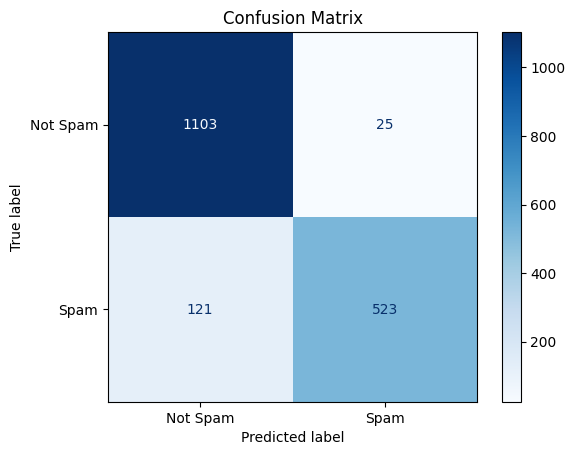


Normalized Confusion Matrix (Proportions):
[[0.98 0.02]
 [0.19 0.81]]


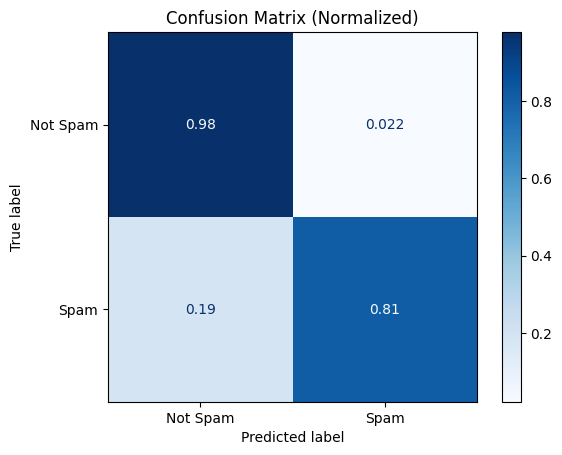


Recall: 0.81
F1-Score: 0.88


In [18]:
# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (Raw Numbers):")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.set_printoptions(precision=2)
print("\nNormalized Confusion Matrix (Proportions):")
print(cm_normalized)


# Plot Normalized Confusion Matrix
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["Not Spam", "Spam"])
disp_normalized.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Normalized)")
plt.show()

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nRecall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

## Step 8:K-Fold Cross-Validation

This step evaluates the **Decision Tree model** using **K-Fold Cross-Validation**. It ensures robust performance testing by splitting the data into multiple training and validation sets.

In [19]:





# Step 8: K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
print("\nK-Fold Results:")

# Perform K-Fold Cross-Validation
for train_index, validate_index in kf.split(X_train_resampled, y_train_resampled):
    # Split the data into training and validation sets
    X_train_fold = X_train_resampled[train_index]
    X_validate_fold = X_train_resampled[validate_index]
    y_train_fold = y_train_resampled[train_index]
    y_validate_fold = y_train_resampled[validate_index]

    # Train the Decision Tree
    decision_tree.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_pred_fold = decision_tree.predict(X_validate_fold)

    # Evaluate performance
    fold_accuracy = accuracy_score(y_validate_fold, y_pred_fold)
    print(f"Fold #{fold}, Accuracy: {fold_accuracy:.2f}")
    fold += 1




K-Fold Results:
Fold #1, Accuracy: 0.94
Fold #2, Accuracy: 0.92
Fold #3, Accuracy: 0.93
Fold #4, Accuracy: 0.94
Fold #5, Accuracy: 0.91
